In [1]:
from src import (
    load_simple_price_csv, # used to load simple price data
    VectorizedEngine, # runs the strategy, calculates performance metrics and returns results
    BuyAndHoldStrategy, # specifies strategy rules for position changes
    plot_results # beautiful plot for strategy results
)
import matplotlib.pyplot as plt # used for simple plots

In [2]:
# 0. Loading data
data = load_simple_price_csv("data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-06-18 12:26:08.563 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-06-18 12:26:08.579 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


# Measuring the profits from a trading strategy

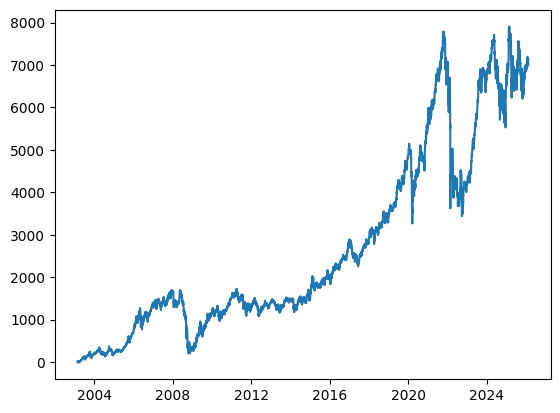

In [3]:
# 1. Account curve (cumulative return) from holding a constant long position in a single unit of Moscow Stock Exchange Index fund contract.
initial_capital = data.iloc[0,0] # set the initial capital equal to 1 contract unit 

bh_strategy = BuyAndHoldStrategy(position_size=1.0)
engine = VectorizedEngine(
    initial_capital = initial_capital
)

bh_result = engine.run(bh_strategy, data) # run the strategy

# plot the results for equity curve
plt.plot(bh_result.equity-initial_capital)

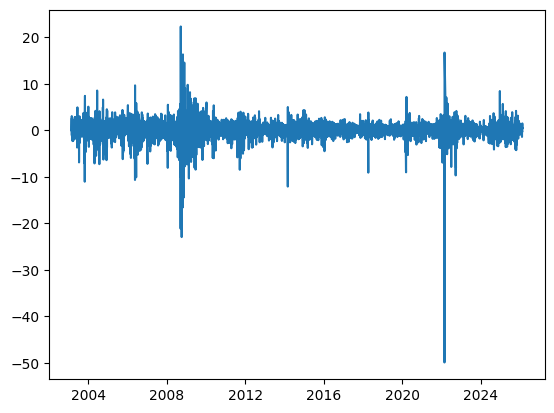

In [4]:
# 2. Percentage returns from buy & hold single contract strategy in MCFTR
plt.plot(bh_result.daily_pnl/bh_result.equity*100)

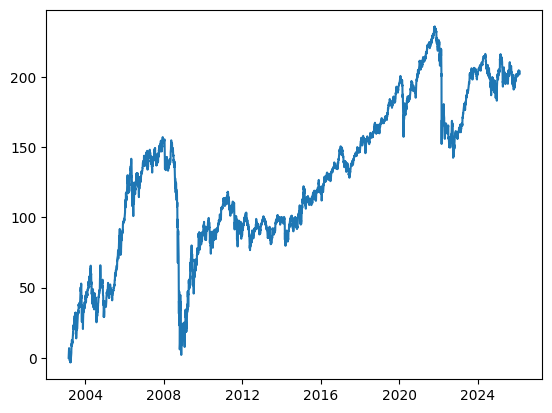

In [5]:
# 3. Account curve (cumulated sum of percentage returns) from buy and hold MCFTR
plt.plot((bh_result.daily_pnl/bh_result.equity*100).cumsum())

# Assessing Performance Characteristics

In [6]:
bh_result.print_metrics()

📊 Backtest Metrics:
  total_return_pct: 2125.46
  cagr_pct: 14.60
  annual_volatility_pct: 30.03
  sharpe_ratio: 0.49
  max_drawdown_pct: -73.57
  avg_drawdown_pct: -4.43
  final_equity: 7470.19
  skew: -0.47
  lower_tail: 2.22
  upper_tail: 1.64
  tail_risk: 1.91


In [7]:
bh_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: BuyAndHoldStrategy                       │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                   +14.6% │
│ Average drawdown                         │                    -4.4% │
│ Maximum drawdown                         │                   -73.6% │
│ Annualised standard deviation            │                    30.0% │
│ Sharpe ratio                             │                     0.49 │
│ Skew                                     │                    -0.47 │
│ Lower tail                               │                     2.22 │
│ Upper tail                               │                     1.64 │
└──────────────────────────────────────────────────────────────────────┘


c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\mpl_plots.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


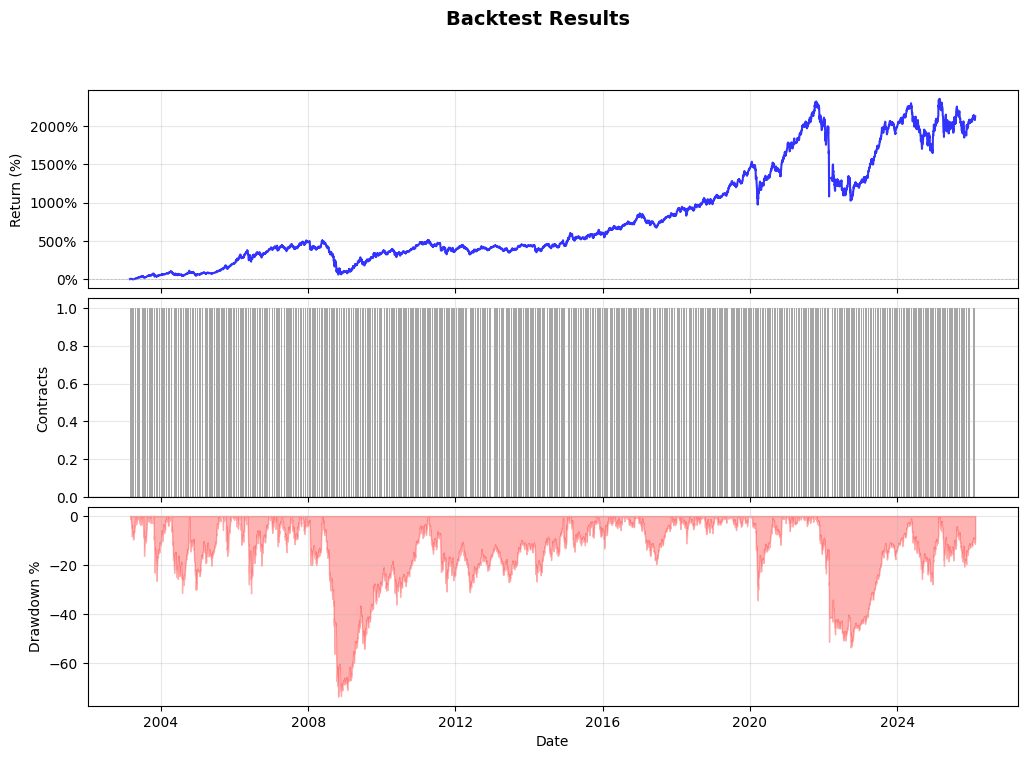

In [8]:
plot_results(bh_result, plot_pct=True)